<a href="https://colab.research.google.com/github/JSJeong-me/Stable_Diffusion/blob/main/01%20LLM-Grounded%20Diffuser%20Model/Stable_Diffusion_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Colab(구글 코랩) 환경에서 GPU를 사용하여 안정적으로 Stable Diffusion을 실행할 수 있도록 정리한 전체 코드입니다.

코랩에서 실행하기 전, [런타임] -> [런타임 유형 변경] -> [하드웨어 가속기]를 'T4 GPU'로 반드시 설정해 주세요.

---

### 1단계: 필수 라이브러리 설치

코랩 환경에는 기본적으로 PyTorch가 설치되어 있으므로, Hugging Face의 `diffusers`와 모델 로드 및 최적화를 위한 `transformers`, `accelerate`를 추가로 설치합니다.

In [ ]:
# 코랩 셀에서 실행 시 앞의 !를 포함하여 실행하세요.
!pip install diffusers transformers accelerate

### 2단계: 라이브러리 임포트 및 GPU 체크

GPU 가속이 정상적으로 활성화되었는지 확인하고 필요한 모듈을 불러옵니다.

In [2]:
import torch
from diffusers import StableDiffusionPipeline, DDPMScheduler, EulerDiscreteScheduler
import PIL.Image

# GPU 사용 가능 여부 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"현재 사용 중인 장치: {device}")
if device == "cpu":
    print("⚠️ 경고: GPU가 활성화되지 않았습니다. 런타임 유형을 T4 GPU로 변경하는 것을 권장합니다.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


현재 사용 중인 장치: cuda


### 3단계: 기본 Stable Diffusion 파이프라인 구동 (DDPM 스케줄러)

Hugging Face 허브에서 정식 `stable-diffusion-v1-4` 모델을 `fp16`(반정밀도) 모드로 다운로드하여 이미지를 생성합니다. 생성된 이미지는 코랩 화면에 즉시 표시되고 파일로도 저장됩니다.

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

이미지 생성 중... (약 10~20초 소요)


  0%|          | 0/30 [00:00<?, ?it/s]

이미지가 'cat_ddpm.png'로 저장되었습니다.


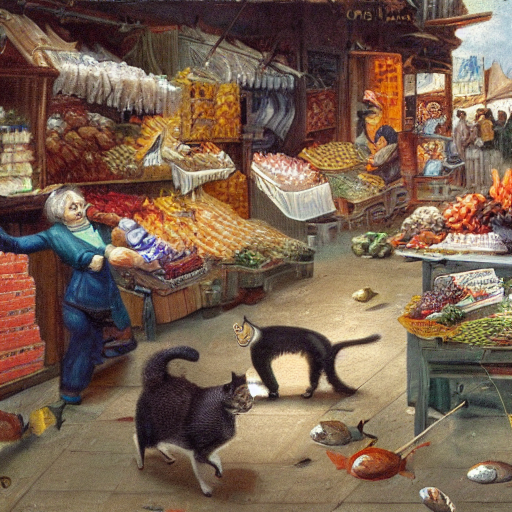

In [3]:
# 1. 원격 허브에서 모델 파이프라인 로드 (메모리 절약을 위해 fp16 사용)
model_id = "CompVis/stable-diffusion-v1-4"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    variant="fp16",
    torch_dtype=torch.float16
)
pipe.to(device)

# 2. 기본 DDPM 스케줄러 설정
scheduler = DDPMScheduler(
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear"
)

# 3. 프롬프트 및 가중치 설정 후 이미지 생성
prompt = "A cat took a fish and running in a market, highly detailed, oil painting"

print("이미지 생성 중... (약 10~20초 소요)")
image_result = pipe(
    prompt,
    scheduler=scheduler,
    num_inference_steps=30,  # 추론 단계 수
    guidance_scale=7.5       # 프롬프트 반영 가중치 (CFG Scale)
).images[0]

# 4. 이미지 저장 및 코랩 출력창에 표시
image_result.save("cat_ddpm.png")
print("이미지가 'cat_ddpm.png'로 저장되었습니다.")
image_result

### 4단계: 더 빠른 스케줄러로 변경하여 생성 (Euler 스케줄러)

가이드 내용 중 스케줄러를 교체하는 예제입니다. `EulerDiscreteScheduler`는 적은 단계(Steps)로도 고품질 이미지를 빠르게 뽑아낼 수 있어 자주 쓰입니다.

Euler 스케줄러를 사용하여 이미지 생성 중...


  0%|          | 0/25 [00:00<?, ?it/s]

이미지가 'cat_euler.png'로 저장되었습니다.


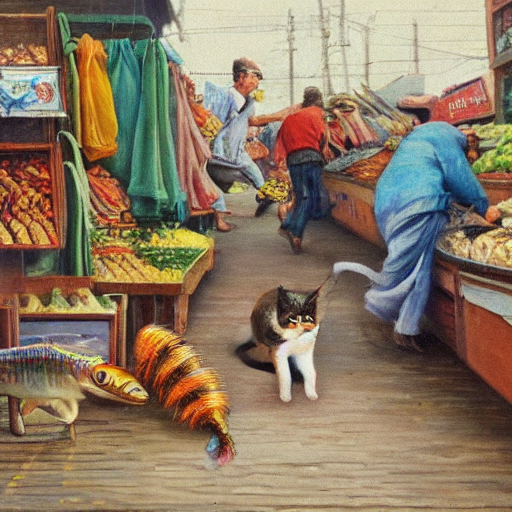

In [4]:
# 1. 오일러 스케줄러 정의
euler_scheduler = EulerDiscreteScheduler(
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear"
)

# 2. 파이프라인을 그대로 유지한 채 스케줄러만 교체하여 실행
print("Euler 스케줄러를 사용하여 이미지 생성 중...")
fast_image = pipe(
    prompt,
    scheduler=euler_scheduler,
    num_inference_steps=25,  # 스케줄러가 효율적이므로 단계를 조금 줄여도 좋습니다.
    guidance_scale=7.5
).images[0]

# 3. 이미지 저장 및 표시
fast_image.save("cat_euler.png")
print("이미지가 'cat_euler.png'로 저장되었습니다.")
fast_image

---

### 💡 코랩 사용 팁 (`.safetensors` 로컬 가중치 파일 관련)

만약 가이드의 3번째 내용처럼 개별 다운로드한 `.safetensors` 파일(예: Civitai나 외부에서 받은 체크포인트)을 코랩에서 사용하고 싶다면 아래와 같이 구글 드라이브를 연동하여 사용할 수 있습니다.

In [ ]:
# 구글 드라이브 연동 (필요 시 주석 해제 후 사용)
# from google.colab import drive
# drive.mount('/content/drive')

# 드라이브에 업로드한 단일 파일 로드 예시
# model_path = "/content/drive/MyDrive/models/realisticVisionV60B1_v60B1VAE.safetensors"
# pipe = StableDiffusionPipeline.from_single_file(model_path, torch_dtype=torch.float16)
# pipe.to("cuda")